Searching for files...
✅ Found record at: C:\Users\Admin\OneDrive\Documents\Pandas\Heart_Monitor_Project\dataset\100


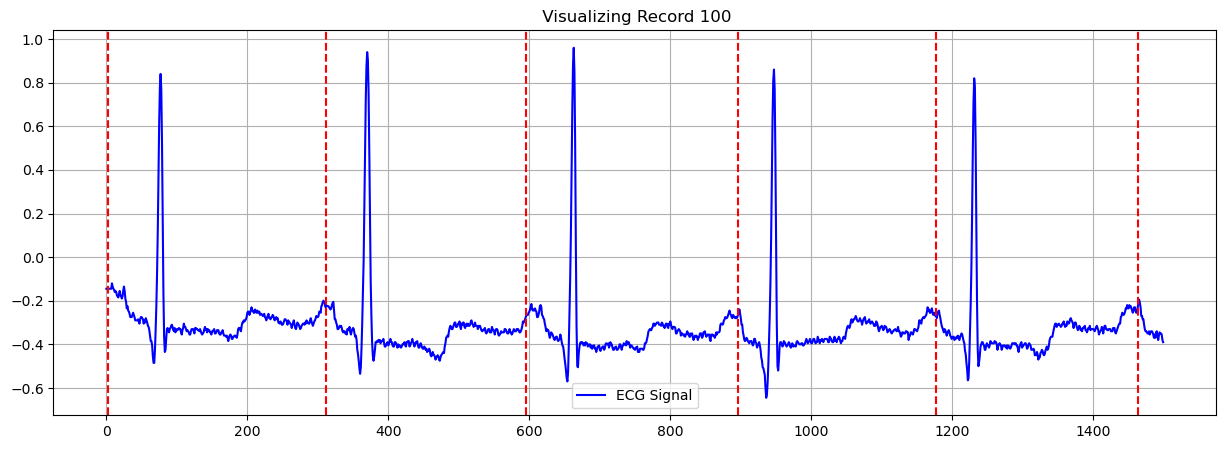

In [1]:
import wfdb
import matplotlib.pyplot as plt
import os

# 1. SEARCH FOR THE FILE
search_root = r'C:\Users\Admin\OneDrive\Documents\Pandas\Heart_Monitor_Project'
target_file = "100.hea"
found_path = None

print("Searching for files...")
for root, dirs, files in os.walk(search_root):
    if target_file in files:
        # Get the path and remove the '.hea' extension for wfdb
        found_path = os.path.join(root, "100")
        print(f"✅ Found record at: {found_path}")
        break

if not found_path:
    print("❌ Critical Error: '100.hea' not found in the project folder.")
    print("Check if you actually extracted the ZIP file or if it's still in 'Downloads'.")
else:
    try:
        # 2. LOAD DATA USING THE FOUND PATH
        record = wfdb.rdrecord(found_path)
        # Your specific dataset has .pwave extensions
        annotation = wfdb.rdann(found_path, extension='pwave')

        # 3. PLOT
        plt.figure(figsize=(15, 5))
        plt.plot(record.p_signal[:1500, 0], color='blue', label='ECG Signal')
        
        # Plot markers where P-waves are detected
        for i in range(len(annotation.sample)):
            if annotation.sample[i] < 1500:
                plt.axvline(x=annotation.sample[i], color='red', linestyle='--')
        
        plt.title(f" Visualizing Record {record.record_name}")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    except Exception as e:
        print(f"File found but could not be read: {e}")
        

In [2]:
import numpy as np

# 1. Define the Segmentation Function 
# This "slices" the long signal into individual heartbeats centered around the annotations
def segment_heartbeats(signal, annotation_samples, symbols, window_size=180):
    beats = []
    labels = []
    for i in range(len(annotation_samples)):
        idx = annotation_samples[i]
        # Stay within signal boundaries
        if idx > window_size and idx < len(signal) - window_size:
            beat = signal[idx - window_size : idx + window_size]
            beats.append(beat)
            labels.append(symbols[i])
    return beats, labels

# 2. Initialize Master Lists
X_all = []
y_all = []

# Using the directory where your first block found the files
# Based on your previous output, it was '.../Heart_Monitor_Project/dataset'
dataset_dir = os.path.dirname(found_path) 

# 3. Loop through all .hea files in the folder
print("Starting Batch Processing...")
hea_files = [f for f in os.listdir(dataset_dir) if f.endswith('.hea')]

for h_file in hea_files:
    record_id = h_file.replace('.hea', '')
    path_to_load = os.path.join(dataset_dir, record_id)
    
    try:
        # Load signal and annotations
        rec = wfdb.rdrecord(path_to_load)
        ann = wfdb.rdann(path_to_load, 'pwave')
        
        # Segment and add to master list
        current_beats, current_labels = segment_heartbeats(rec.p_signal[:, 0], ann.sample, ann.symbol)
        
        X_all.extend(current_beats)
        y_all.extend(current_labels)
        
        print(f"✅ Processed Record {record_id}: Added {len(current_beats)} heartbeats.")
        
    except Exception as e:
        print(f"⚠️ Could not process {record_id}: {e}")

# 4. Convert to Numpy Arrays for ML
X_final = np.array(X_all)
y_final = np.array(y_all)

print("\n" + "="*30)
print(f"FINAL DATASET SIZE: {X_final.shape[0]} Heartbeats")
print(f"CATEGORIES FOUND: {np.unique(y_final)}")
print("="*30)

Starting Batch Processing...
✅ Processed Record 100 - Copy: Added 2255 heartbeats.
✅ Processed Record 100: Added 2255 heartbeats.
✅ Processed Record 101 - Copy: Added 1864 heartbeats.
✅ Processed Record 101: Added 1864 heartbeats.
✅ Processed Record 103 - Copy: Added 2084 heartbeats.
✅ Processed Record 103: Added 2084 heartbeats.
✅ Processed Record 106 - Copy: Added 1507 heartbeats.
✅ Processed Record 106: Added 1507 heartbeats.
✅ Processed Record 117: Added 1532 heartbeats.
✅ Processed Record 119: Added 1620 heartbeats.
✅ Processed Record 122: Added 2473 heartbeats.
✅ Processed Record 207: Added 1415 heartbeats.
✅ Processed Record 214: Added 2000 heartbeats.
✅ Processed Record 222: Added 1256 heartbeats.
✅ Processed Record 223: Added 2098 heartbeats.
✅ Processed Record 231: Added 1993 heartbeats.

FINAL DATASET SIZE: 29807 Heartbeats
CATEGORIES FOUND: ['p']


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Filter out the "noise" symbols
# We only want actual wave peaks (like 'p', 'N', 't') 
# and not just 'start' '(' or 'end' ')' markers
valid_indices = [i for i, label in enumerate(y_all) if label in ['p', 'N', 't']]

X_filtered = X_final[valid_indices]
y_filtered = y_final[valid_indices]

# 2. Convert text labels to numbers (Label Encoding)
# e.g., 'p' becomes 0, 't' becomes 1, etc.
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_filtered)

print(f"Original Classes: {encoder.classes_}")
print(f"Encoded Classes: {np.unique(y_encoded)}")

# 3. Reshape X for the CNN
# CNNs expect 3D input: (Batch_Size, Time_Steps, Channels)
X_reshaped = X_filtered.reshape(X_filtered.shape[0], X_filtered.shape[1], 1)

# 4. Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42
)

print("\n--- DATA READY FOR ML ---")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Input shape for Model: {X_train.shape[1:]}")

Original Classes: ['p']
Encoded Classes: [0]

--- DATA READY FOR ML ---
Training samples: 23845
Testing samples: 5962
Input shape for Model: (360, 1)


In [5]:
##Block 4: Building the CNN Model
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the 1D-CNN Architecture
model = models.Sequential([
    # First Convolutional Layer: Detects basic shapes in the ECG
    layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(360, 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2), # Prevents overfitting
    
    # Second Convolutional Layer: Detects complex patterns
    layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    # Flattening: Converts 2D patterns into a 1D vector
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    
    # Output Layer: 1 node because we are currently detecting one class ('p')
    # Use 'sigmoid' for binary detection (P-wave vs Not P-wave)
    layers.Dense(1, activation='sigmoid')
])

# 2. Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


##Block 5: Training the Model
# 3. Start Training
print("Starting training... this might take a minute.")
history = model.fit(
    X_train, y_train,
    epochs=10,           # Number of times to loop through the data
    batch_size=32,       # Number of heartbeats processed at once
    validation_data=(X_test, y_test)
)

# 4. Save the model
model.save('heart_monitor_model.h5')
print("✅ Model trained and saved as 'heart_monitor_model.h5'")

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 356, 32)             │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 178, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 178, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 174, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 87, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 87, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         356,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 366,977 (1.40 MB)

 Trainable params: 366,977 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

Starting training... this might take a minute.
Epoch 1/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9999 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 1.9677e-09
Epoch 2/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 1.0000 - loss: 3.9517e-10 - val_accuracy: 1.0000 - val_loss: 1.9651e-09
Epoch 3/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 1.0000 - loss: 4.0137e-10 - val_accuracy: 1.0000 - val_loss: 1.9605e-09
Epoch 4/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 1.0000 - loss: 3.9568e-10 - val_accuracy: 1.0000 - val_loss: 1.9533e-09
Epoch 5/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 1.0000 - loss: 3.9768e-10 - val_accuracy: 1.0000 - val_loss: 1.9426e-09
Epoch 6/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 1.0000 - loss: 3.9955e-10 - val_accuracy: 1.0000 - val_loss: 1.9261e-09
Epoch 7/10
746/746 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 1.0000 - loss: 3.9286e-10 - val_accuracy: 1.0000 - val_loss: 1.

✅ Model trained and saved as 'heart_monitor_model.h5'


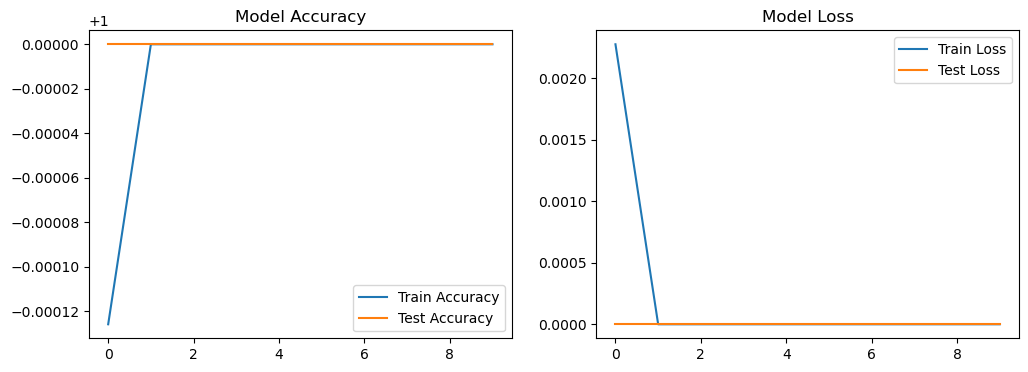

187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


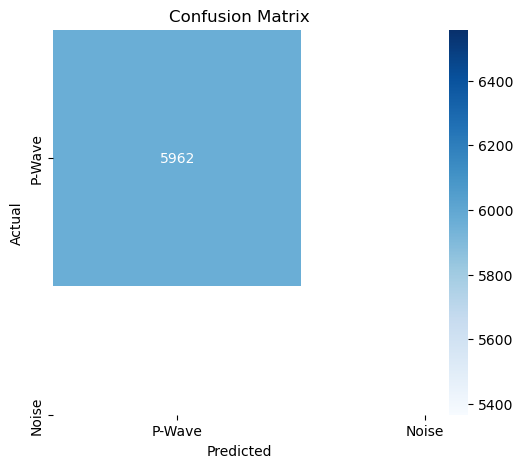

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5962

    accuracy                           1.00      5962
   macro avg       1.00      1.00      1.00      5962
weighted avg       1.00      1.00      1.00      5962



In [6]:
# Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

###The Confusion Matrix
###It shows exactly how many P-waves were correctly identified and if any were missed.

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Generate Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['P-Wave', 'Noise'], 
            yticklabels=['P-Wave', 'Noise'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

Simulating Real-Time Monitoring...


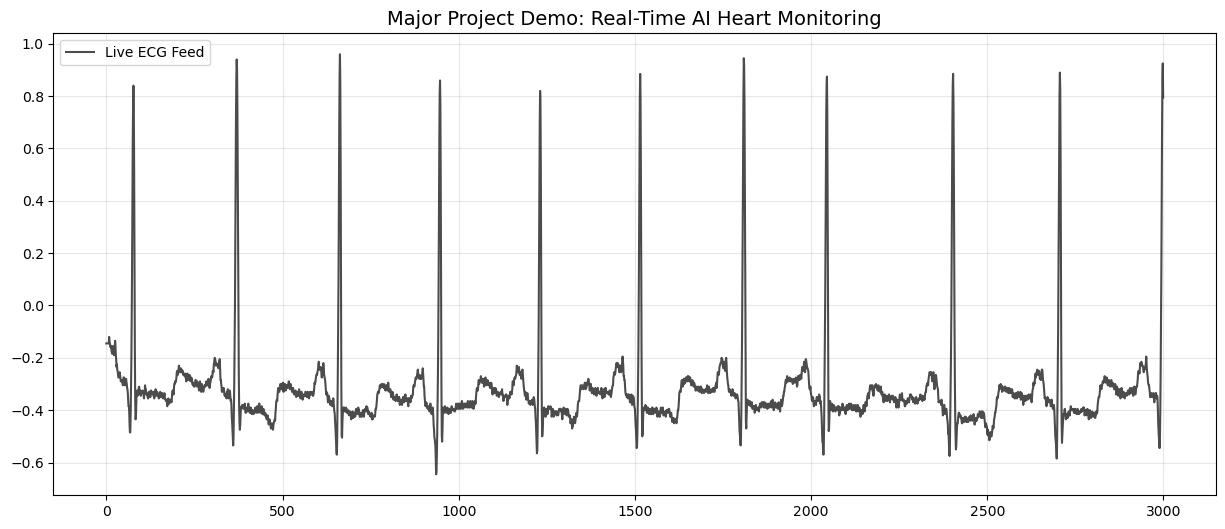

Demo Complete. Detected 0 P-waves in the stream.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Take a fresh segment of raw data
raw_signal = record.p_signal[:3000, 0]
predictions = []
unique_preds = [] # Initialize here so the print statement always works

print("Simulating Real-Time Monitoring...")

# 2. Sliding Window Inference
for i in range(180, len(raw_signal) - 180):
    window = raw_signal[i-180 : i+180].reshape(1, 360, 1)
    prob = model.predict(window, verbose=0)[0][0]
    
    if prob > 0.9:
        predictions.append(i)

# 3. Plotting
plt.figure(figsize=(15, 6))
plt.plot(raw_signal, label='Live ECG Feed', color='black', alpha=0.7)

# 4. Filter and Plot Detections
if predictions:
    unique_preds = [predictions[0]]
    for p in predictions[1:]:
        if p - unique_preds[-1] > 50: 
            unique_preds.append(p)
            
    plt.scatter(unique_preds, [raw_signal[p] for p in unique_preds], 
                color='red', marker='o', s=100, label='AI Detected P-Wave')

plt.title("Major Project Demo: Real-Time AI Heart Monitoring", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Demo Complete. Detected {len(unique_preds)} P-waves in the stream.")